Marketing ROI analaysis using TV, Radio and Social Media as features.
dependent variable/ target variable is Sales, while the independent variables/features are TV, Radio and Social Media.
The goal of this project is to recommed the marketing channel with the strongest ROI impact

import libraries and packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import scipy.stats as stats

Load marketing dataset

In [2]:
df = pd.read_csv('marketing.csv')

In [3]:
df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [4]:
df.tail()

,TV,Radio,Social_Media,Sales
4567,26.0,4.472360,0.717090,94.685866
4568,71.0,20.610685,6.545573,249.101915
4569,44.0,19.800072,5.096192,163.631457
4570,71.0,17.534640,1.940873,253.610411
4571,42.0,15.966688,5.046548,148.202414


In [5]:
df.shape

(4572, 4)

In [6]:
df.size

18288

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


Statistical information

In [8]:
df.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


Exploratory Data Analysis (EDA)

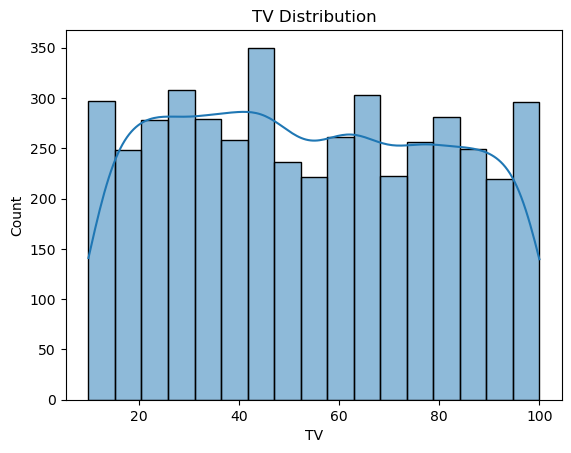

In [9]:
sns.histplot(x=df['TV'], data=df, kde=True)
plt.title('TV Distribution')
plt.show()

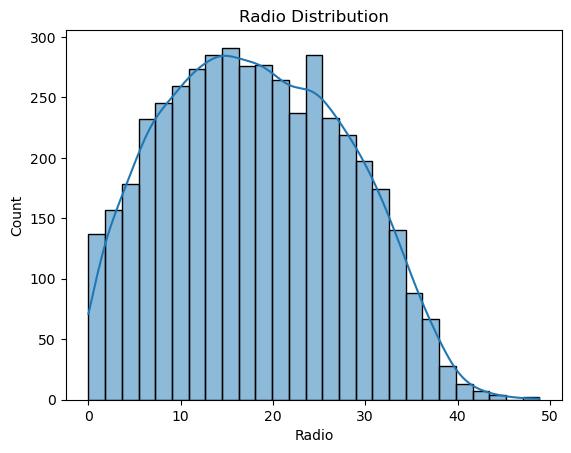

In [10]:
sns.histplot(x=df['Radio'], data=df, kde=True)
plt.title('Radio Distribution')
plt.show()

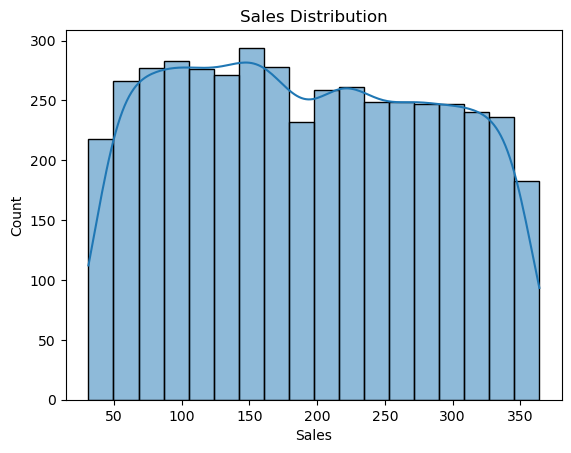

In [11]:
sns.histplot(x=df['Sales'], data=df, kde=True)
plt.title('Sales Distribution')
plt.show()

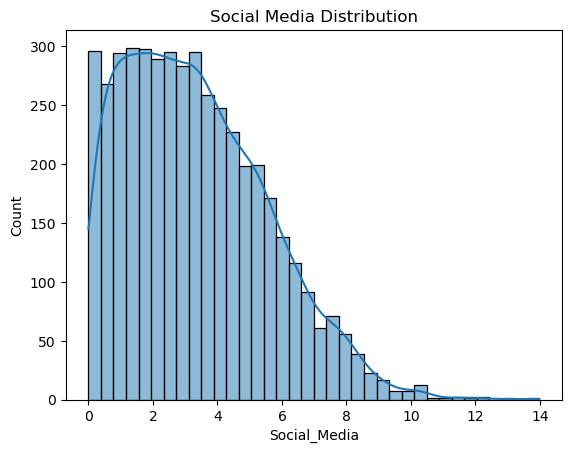

In [12]:
sns.histplot(x=df['Social_Media'], data=df, kde=True)
plt.title('Social Media Distribution')
plt.show()

In [13]:
df.corr()

,TV,Radio,Social_Media,Sales
TV,1.000000,0.869460,0.528168,0.999497
Radio,0.869460,1.000000,0.607452,0.869105
Social_Media,0.528168,0.607452,1.000000,0.528906
Sales,0.999497,0.869105,0.528906,1.000000


From the correlation Table, TV has a very Strong correlation with sales, while Radio has a strong correlation with Sales, Social_Media Has a Moderate correlation with Sales. TV > Radio > Social_Media.

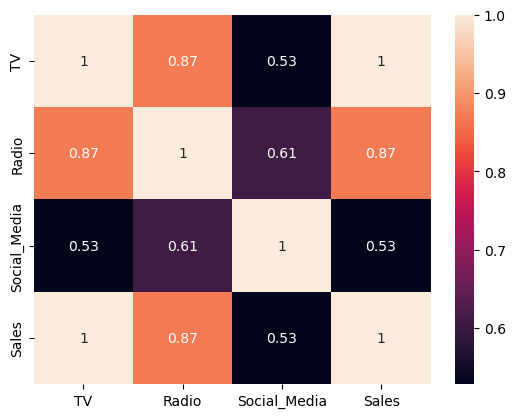

In [14]:
sns.heatmap(df.corr(), annot=True)
plt.show()

This gives a visual explanation of the correlation between TV, Social_Media and Radio. TV has an almost perfect correlation with Sales
TV has a higher impact on sales

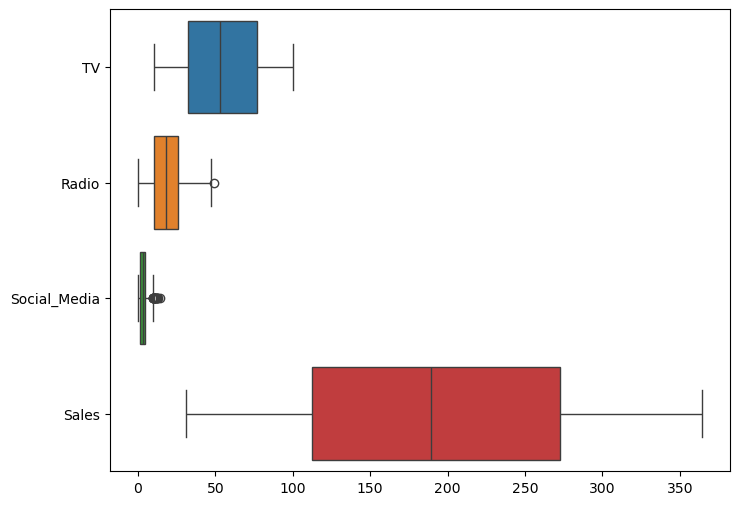

In [15]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, orient='h')
plt.show()

From the Box plot above we can see that Radio and Social Media Contains Outliers as indicated by the dot above the whiskers. these are unsual values in our datasets

In [16]:
cols = df.columns
cols

Index(['TV', 'Radio', 'Social_Media', 'Sales'], dtype='object')

In this dataset the independent variables also called features are TV, Social_Media and Radio. while the dependent variable or the target variable is Sales. our goal is to predict and draw uselful conclusions on how these features affect sales. for this project i used 70% of the dataset to train the model and 30% to validate our model

drop missing values in our target variables (Sales) as filling it will hurt the model.

In [17]:
df = df.dropna(subset=['Sales'])

In [18]:
X = df.drop('Sales', axis=1)

In [19]:
y = df['Sales']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Missing Values in our features

In [21]:
def missing_values_report(X_train, X_test):
    missing_count_train = X_train.isnull().sum()
    missing_count_test = X_test.isnull().sum()
    
    missing_pct_train = (X_train.isnull().sum()/len(X_train))*100
    missing_pct_test = (X_test.isnull().sum()/len(X_test))*100
    
    report = pd.DataFrame({
    'missing_count_train': missing_count_train,
    'missing_count_test': missing_count_test,
    'missing_%_train': missing_pct_train.round(2),
    'missing_%_test': missing_pct_test.round(2)
    })
    report = report[report['missing_count_train']>0].sort_values('missing_%_train', ascending=False)
    if report.empty:
        return 'No missing values found'
    return report

In [22]:
missing_values_report(X_train, X_test)

,missing_count_train,missing_count_test,missing_%_train,missing_%_test
TV,7,3,0.22,0.22
Social_Media,4,2,0.13,0.15
Radio,3,1,0.09,0.07


filling missing values in our features based on the distribution of the histogram, median are sensitive to outliers and from our boxplot Radio and TV contains outliers and missing values. we also fill Social Media with median

In [23]:
def filling_values_report(X_train, X_test, strategy='median'):
    imputer = SimpleImputer(strategy=strategy)
    
    X_train_filled=pd.DataFrame(
        imputer.fit_transform(X_train),
        columns = X_train.columns,
        index = X_train.index
    )
    X_test_filled = pd.DataFrame(
        imputer.fit_transform(X_test),
        columns = X_test.columns,
        index = X_test.index
     )
    return X_train_filled, X_test_filled

In [24]:
X_train, X_test = filling_values_report(X_train, X_test, strategy='median')

after filling missing values our dataset no longer contains missing values

In [25]:
X_train.isna().sum()

TV              0
Radio           0
Social_Media    0
dtype: int64

In [26]:
X_test.isna().sum()

TV              0
Radio           0
Social_Media    0
dtype: int64

Fitting the OLS model on our training dataset

In [27]:
def ols_model(X_train, y_train, X_test):
    X_train = sm.add_constant(X_train, has_constant='add')
    X_test = sm.add_constant(X_test, has_constant = 'add')

    model = sm.OLS(y_train, X_train).fit()
    return model, X_train, X_test

In [28]:
model, X_train, X_test= ols_model(X_train,y_train, X_test)

In [29]:
model, X_train, X_test

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x21d210082f0>,
       const    TV      Radio  Social_Media
 3655    1.0  49.0  17.579874      1.218985
 2659    1.0  82.0  27.298857      2.750433
 3461    1.0  58.0  18.169162      0.137570
 3615    1.0  64.0  20.533171      4.245637
 1569    1.0  76.0  27.796460      3.915785
 ...     ...   ...        ...           ...
 4432    1.0  11.0   0.401649      1.160768
 472     1.0  17.0   8.797291      2.409158
 3098    1.0  92.0  32.167169      6.726771
 3778    1.0  52.0  12.044814      0.370684
 866     1.0  68.0  13.866157      0.040676
 
 [3196 rows x 4 columns],
       const    TV      Radio  Social_Media
 1123    1.0  36.0   5.363570      0.899458
 422     1.0  51.0  24.916486      4.628289
 3593    1.0  21.0   6.753057      1.970540
 2482    1.0  86.0  33.991326      4.794127
 887     1.0  35.0  16.589917      2.529491
 ...     ...   ...        ...           ...
 3747    1.0  99.0  33.381723      8.147555
 1681    1

In [30]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 2.499e+05
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:57:31   Log-Likelihood:                -10296.
No. Observations:                3196   AIC:                         2.060e+04
Df Residuals:                    3192   BIC:                         2.062e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.1089      0.253     -0.431   

In [31]:
y_pred = model.predict(X_test)

In [32]:
y_pred.head()

1123    127.358642
422     182.556841
3593     74.734090
2482    306.850450
887     125.151517
dtype: float64

In [33]:
print('Test R^2:', r2_score(y_test, y_pred))

Test R^2: 0.9941494853861397


In [34]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print('Test RMSE:', rmse)

Test RMSE: 7.110743303837819


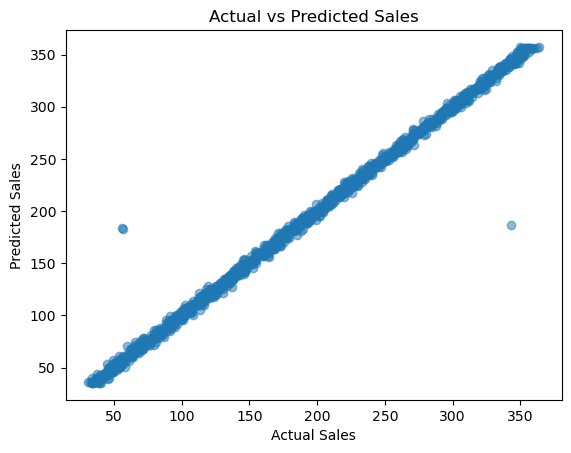

In [35]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()

Actual plot vsersus Predicted Plot

Residuals vs fitted for Homoscedasticity

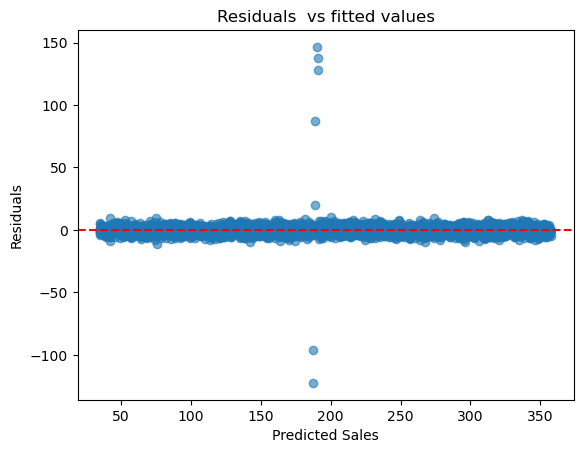

In [36]:
residuals= y_test - y_pred
plt.scatter(model.fittedvalues, model.resid, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residuals  vs fitted values')
plt.show()

Residuals vs Predicted Plot for Sales

Q-Q plot for Normality

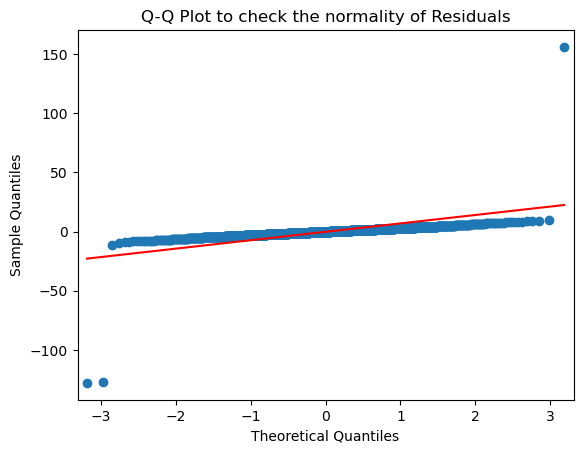

In [37]:
sm.qqplot(residuals, line ='s')
plt.title('Q-Q Plot to check the normality of Residuals')
plt.show()

Q -Q Pot

OLS parameters

1. P|t| < 0.05 (significance/useful/important)
2. P|t| > 0.05 (noise, no real impact)
3. coef = how much significance
4. R^2 = % of Sales variance Explained by TV, Radio and Social Media. 

from the OLS Regression Summary
1.The model gave an R2 of 0.996, This implies that 99.6% of Sales is explained by the features (TV, Radio and Social Media).

2. P|t|  tells us which of these features are significant  or not. < 0.05 shows that a feature is useful and should be kept, while P|t| > 0.05 signals that a feature should be dropped as it holds no significance. so it is evident that TV ( 0.00) and Radio (0.00) are more significant/ useful than Social Media. and hence TV and Radio Should be kept while Social Media (0.263) should be dropped as it is a noise rather than signal.

3. Coefficient ( coef): TV coef,how much Sales changes per 1 unit Change in TV. So for every +1 unit spent on TV --> +3.5231 units in sales, and this makes sense because from our corr chart and heat map. TV has a Strong Correlation with Sales. Radio coef= 0.1074 also significant , every +1 on Radio gives +0.11 on Sales. Small effect as compared to TV.
   Social_Media coef=0.0675, has negligible chnage on Sales,  +0.0675 on sales,
 
4. So in this Analysis TV is the driving forces for sales as it gives a hiher return of 3.52X, Radio has a small but real impact, while Social Media adds nothing meaningful to Sales

                                 Recommendation
TV is the main driver of Sales with 3.523x ROI, budget for Social Media Should be re-allocated to TV for higher returns

In [38]:

print(f"Sales = {model.params['const']:.3f} + {model.params['TV']:.3f}*TV + {model.params['Radio']:.3f}*Radio + {model.params['Social_Media']:.3f}*Social_Media")

Sales = -0.109 + 3.523*TV + 0.107*Radio + 0.068*Social_Media
